In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn import svm, tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, RobustScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

data = pd.read_csv("data/ortodoncja.csv")

In [2]:
columns = ["9_SN/MP", "9_Facial axis", "9_Y-axis", "9_SNPog", "9_SNB", "9_SNA", "9_Mn Ramus Angle",
           "9_Mn Base angle", "9_AFH:PFH", "12_SN/MP", "12_Facial axis", "12_Y-axis", "12_SNPog",
           "12_SNB", "12_SNA", "12_Mn Ramus Angle", "12_AFH:PFH"]


# data = data.iloc[:, -4:]
print(data.groupby("growth direction").count())
data.info()
# data = data.drop(columns, axis="columns")

                  9_SN/MP  9_Facial axis  9_Y-axis  9_Mn Base angle  \
growth direction                                                      
horizontal            184            184       184              184   
normal                246            246       246              246   
vertical               16             16        16               16   

                  9_Mn Ramus Angle  9_SNPog  9_SNB  9_SNA  9_SN/PP  9_ANB  \
growth direction                                                            
horizontal                     184      184    184    184      184    184   
normal                         246      246    246    246      246    246   
vertical                        16       16     16     16       16     16   

                  ...  12_Mn Base angle  12_Mn Ramus Angle  12_SNPog  12_SNB  \
growth direction  ...                                                          
horizontal        ...               184                184       184     184   
normal            

In [3]:
X = data.drop("growth direction", axis="columns")
X = pd.DataFrame(StandardScaler().fit_transform(X))
y = data["growth direction"]

In [4]:
# growth_direction_to_numbers = {"horizontal": 1, "normal": 0, "vertical": -1}

# X["numeric_growth"] = [growth_direction_to_numbers[growth] for growth in y]

Dropped 11 columns


<Axes: >

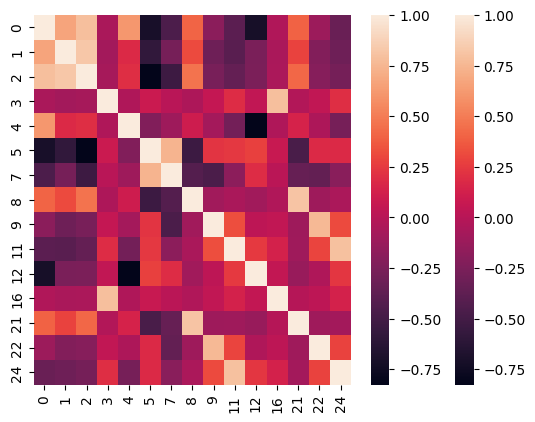

In [5]:
# data.groupby("growth direction")["growth direction"].count()
corr = X.corr()
sb.heatmap(X.corr())

def drop_highly_correlated(df, threshold):
    data = df.select_dtypes(include=[np.number]).copy()
    corr = data.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    print(f"Dropped {len(to_drop)} columns")
    return df.drop(columns=to_drop)

X = drop_highly_correlated(X, threshold=0.85)
sb.heatmap(X.corr())

In [6]:
SEED = 2137
ITERATIONS = 20

GaussianNB    mean:    0.67778  std:    0.03817
Ridge         mean:    0.62667  std:    0.04719
NeuralNetwork mean:    0.75222  std:    0.04023
LinearSVC     mean:    0.68167  std:    0.04420
SVC           mean:    0.72444  std:    0.03826
KNN           mean:    0.62889  std:    0.05097
RandomForest  mean:    0.76000  std:    0.03675
HistGB        mean:    0.75167  std:    0.03869
DecisionTree  mean:    0.69056  std:    0.03723


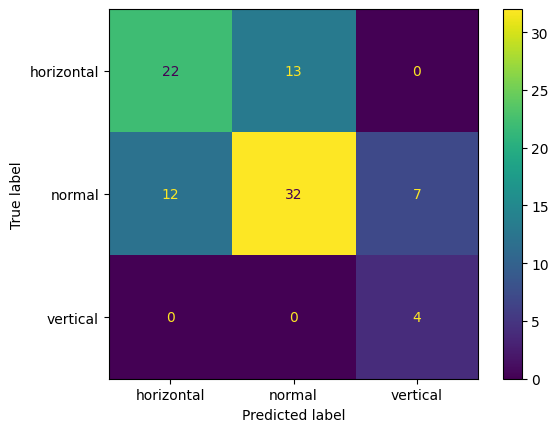

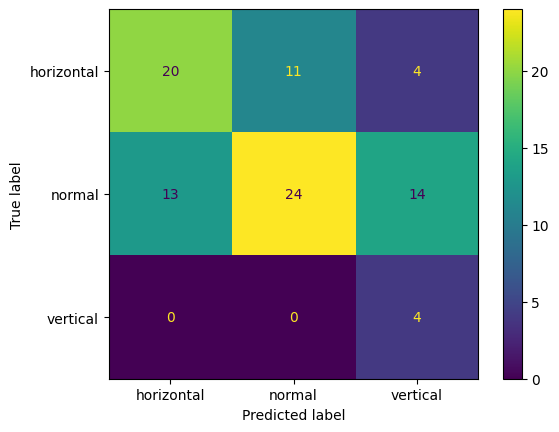

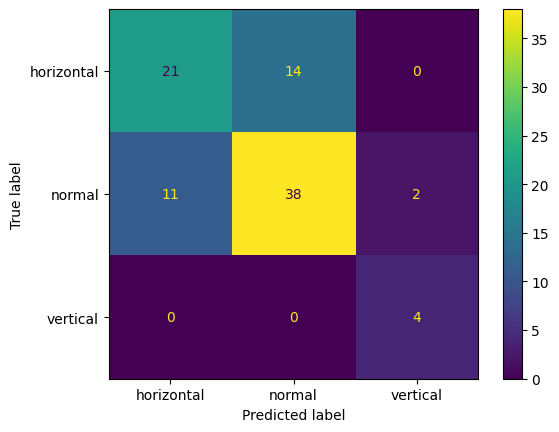

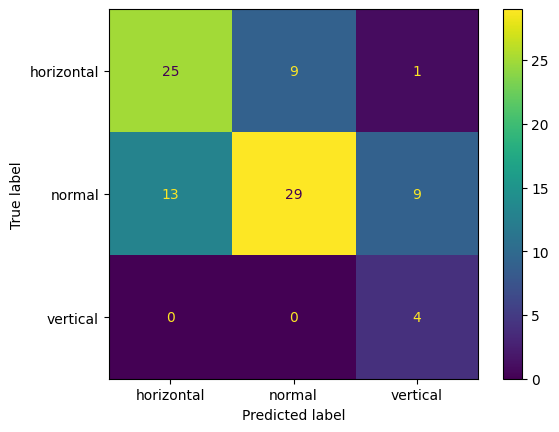

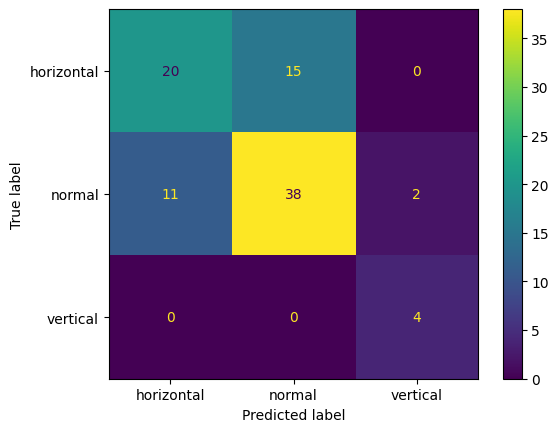

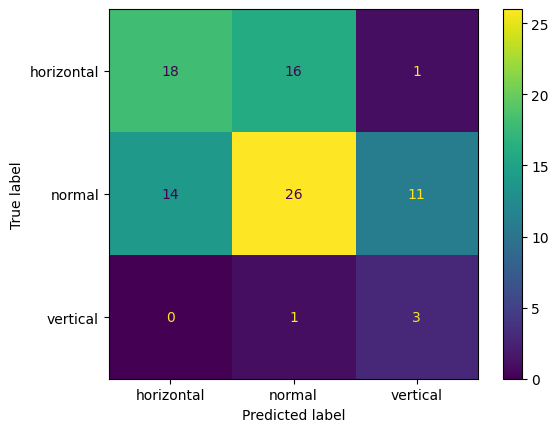

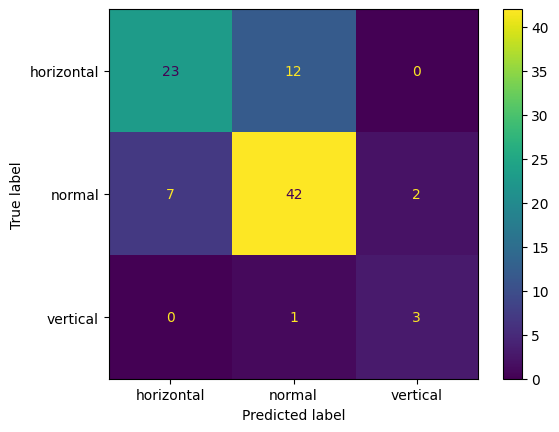

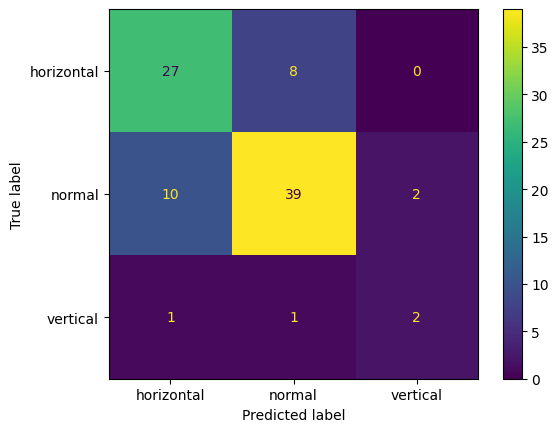

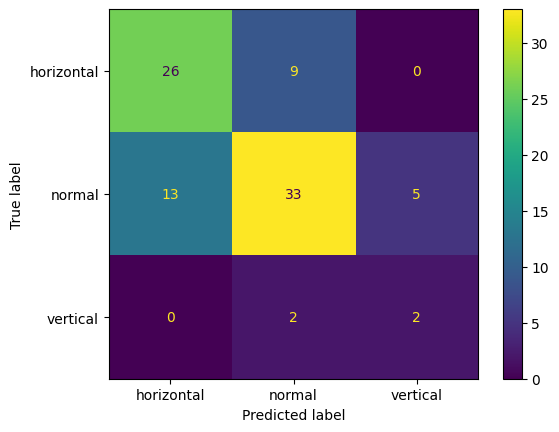

In [7]:
classifiers = [
    ("GaussianNB", GaussianNB),
    ("Ridge", RidgeClassifier),
    ("NeuralNetwork", MLPClassifier),
    ("LinearSVC", svm.LinearSVC),
    ("SVC", svm.SVC),
    ("KNN", KNeighborsClassifier),
    ("RandomForest", RandomForestClassifier),
    ("HistGB", HistGradientBoostingClassifier),
    ("DecisionTree", tree.DecisionTreeClassifier),
]

results = {}
for name, ClfClass in classifiers:
    acc_scores = []
    for i in range(ITERATIONS):
        smote = SMOTE(sampling_strategy='minority', random_state=SEED + i)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED + i)
        X_train_SMOTE, y_train_SMOTE = smote.fit_resample(X_train, y_train)

        kwargs = {}
        if "random_state" in ClfClass().get_params():
            kwargs["random_state"] = SEED + i
        clf = ClfClass(**kwargs)

        clf.fit(X_train_SMOTE, y_train_SMOTE)
        # clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc_scores.append(accuracy_score(y_test, y_pred))

    results[name] = np.array(acc_scores)
    print(f"{name:<13} mean: {results[name].mean():10.5f}  std: {results[name].std():10.5f}")
    cm = confusion_matrix(y_test, y_pred, labels=["horizontal", "normal", "vertical"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot()
